# Transform CRS

In [12]:
# read all file name in "data\Planet_data"

import os

planet_data_dir = "data/Planet_data"
file_names = os.listdir(planet_data_dir)

# remove all names that have ".aux.xml" in them
file_names = [name for name in file_names if not name.endswith(".aux.xml")] 
print(file_names)

['2016-12-19_composite.tif', '2017-03-16_strip_435861_composite.tif', '2017-07-06_strip_602670_composite.tif', '2017-10-15_strip_838927_composite.tif', '2018-02-22_strip_1201956_composite.tif', '2018-06-29_strip_1532242_composite.tif', '2018-06-29_strip_1532242_composite_coastlines.geojson', '2018-10-05_strip_1746499_composite.tif', '2019-02-15_strip_2122432_composite.tif', '2019-06-14_strip_2443911_composite.tif', '2019-06-14_strip_2443911_composite_coastlines.geojson', '2019-10-16_strip_2755420_composite.tif', '2020-02-07_strip_3113467_composite.tif', '2020-06-24_strip_3512625_composite.tif', '2020-06-24_strip_3512625_composite_coastlines.geojson', '2020-10-23_strip_3833704_composite.tif', '2021-03-02_strip_4218715_composite.tif', '2021-06-27_strip_4630194_composite.tif', '2021-06-27_strip_4630194_composite_coastlines.geojson', '2021-10-15_strip_5001262_composite.tif', '2022-03-08_strip_5468490_composite.tif', '2022-06-21_strip_5728503_composite.tif', '2022-06-21_strip_5728503_compos

In [13]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
import os
from affine import Affine

# read tif files in the folder, change their crs to EPSG:28992 and save them in "data\Planet_data_EPSG28992"

out_dir = "data/Planet_data_EPSG28992"
os.makedirs(out_dir, exist_ok=True)
dst_crs = "EPSG:28992"

for name in file_names:
    if not name.lower().endswith(".tif"):
        continue

    src_path = os.path.join(planet_data_dir, name)
    dst_path = os.path.join(out_dir, name)

    with rasterio.open(src_path) as src:
        if src.crs is None:
            print(f"Skipping {name}: source has no CRS")
            continue

        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update({
            "crs": dst_crs,
            "transform": transform,
            "width": width,
            "height": height
        })

        # remove 10% from the edges to avoid black borders after reprojection
        # remove 10% margins from the destination to avoid black borders after reprojection
        dx = int(width * 0.1)
        dy = int(height * 0.1)

        # ensure we don't create non-positive dimensions
        if dx > 0 and dy > 0 and (width - 2 * dx) > 0 and (height - 2 * dy) > 0:
            transform = transform * Affine.translation(dx, dy)
            kwargs.update({
                "transform": transform,
                "width": width - 2 * dx,
                "height": height - 2 * dy
            })

        with rasterio.open(dst_path, "w", **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest
                )
    print(f"Reprojected {name} -> {dst_path}")

Reprojected 2016-12-19_composite.tif -> data/Planet_data_EPSG28992\2016-12-19_composite.tif
Reprojected 2017-03-16_strip_435861_composite.tif -> data/Planet_data_EPSG28992\2017-03-16_strip_435861_composite.tif
Reprojected 2017-07-06_strip_602670_composite.tif -> data/Planet_data_EPSG28992\2017-07-06_strip_602670_composite.tif
Reprojected 2017-10-15_strip_838927_composite.tif -> data/Planet_data_EPSG28992\2017-10-15_strip_838927_composite.tif
Reprojected 2018-02-22_strip_1201956_composite.tif -> data/Planet_data_EPSG28992\2018-02-22_strip_1201956_composite.tif
Reprojected 2018-06-29_strip_1532242_composite.tif -> data/Planet_data_EPSG28992\2018-06-29_strip_1532242_composite.tif
Reprojected 2018-10-05_strip_1746499_composite.tif -> data/Planet_data_EPSG28992\2018-10-05_strip_1746499_composite.tif
Reprojected 2019-02-15_strip_2122432_composite.tif -> data/Planet_data_EPSG28992\2019-02-15_strip_2122432_composite.tif
Reprojected 2019-06-14_strip_2443911_composite.tif -> data/Planet_data_EPS

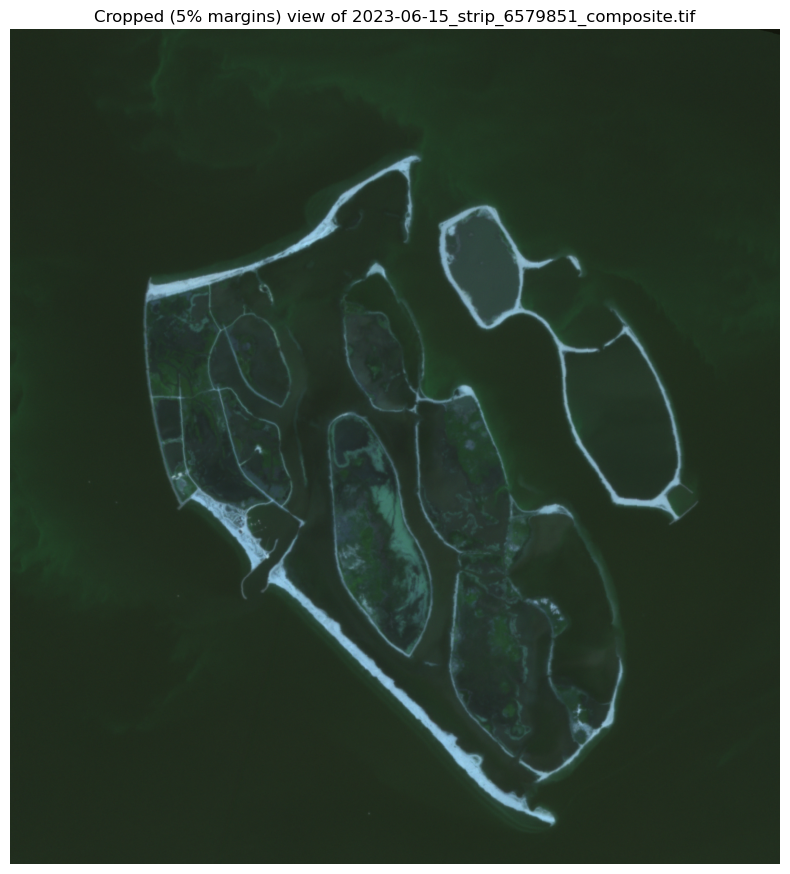

In [ ]:
import os
import numpy as np
import rasterio

# plot the first file by removing 5% from 4 sides

import matplotlib.pyplot as plt

# find first tif in the known file list
first_tif = file_names[25]
if first_tif is None:
    raise FileNotFoundError("No .tif file found in file_names")

# prefer the reprojected file in out_dir, fall back to original folder
candidate_path = os.path.join(out_dir, first_tif)
if not os.path.exists(candidate_path):
    candidate_path = os.path.join(planet_data_dir, first_tif)
    if not os.path.exists(candidate_path):
        raise FileNotFoundError(f"File not found in either '{out_dir}' or '{planet_data_dir}': {first_tif}")

with rasterio.open(candidate_path) as src:
    data = src.read()  # shape: (bands, height, width)
    h, w = src.height, src.width

# compute 5% margins (pixel units)
left = int(w * 0.1)
right = w - left
top = int(h * 0.1)
bottom = h - top

# crop
cropped = data[:, top:bottom, left:right]

# prepare RGB image: use first 3 bands or repeat single band
if cropped.shape[0] >= 3:
    bands = cropped[:3]
else:
    bands = np.vstack([cropped[0:1]] * 3)

rgb = np.transpose(bands, (1, 2, 0)).astype("float32")

# normalize for plotting
mx = rgb.max()
if mx > 0:
    rgb /= mx

plt.figure(figsize=(10, 10 * (rgb.shape[0] / rgb.shape[1])))
plt.imshow(rgb)
plt.axis("off")
plt.title(f"Cropped (5% margins) view of {first_tif}")
plt.show()